In [36]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import plotly.express as px
import seaborn as sns 

In [37]:
heart_attack_df = pd.read_csv ('heart_attack_prediction_dataset_edit (1).csv')
heart_attack_df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67.0,m,208,158/88,72,0.0,0.0,1,0,...,6.615001,261404.0,31.251233,286,0,6.0,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21.0,male,389,165/93,98,1.0,1.0,1,1,...,4.963459,285768.0,27.194973,235,1,7.0,Canada,North America,Northern Hemisphere,0
2,BNI9906,21.0,Female,324,174/99,72,1.0,0.0,0,0,...,9.463426,235282.0,28.176571,587,4,4.0,France,Europe,Northern Hemisphere,0
3,JLN3497,84.0,NaN,383,163/100,73,1.0,1.0,1,0,...,7.648981,125640.0,36.464704,378,3,4.0,Canada,North America,Northern Hemisphere,0
4,GFO8847,66.0,Male,318,91/88,93,NaN,1.0,1,1,...,1.514821,160555.0,21.809144,231,1,5.0,Thailand,Asia,Northern Hemisphere,0


In [38]:
heart_attack_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8761 non-null   float64
 2   Sex                              8762 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8762 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8762 non-null   float64
 7   Family History                   8762 non-null   float64
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [39]:
heart_attack_df.shape 

(8763, 26)

In [40]:
heart_attack_df = heart_attack_df.dropna(axis=0).copy()
heart_attack_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8754 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8754 non-null   object 
 1   Age                              8754 non-null   float64
 2   Sex                              8754 non-null   object 
 3   Cholesterol                      8754 non-null   int64  
 4   Blood Pressure                   8754 non-null   object 
 5   Heart Rate                       8754 non-null   int64  
 6   Diabetes                         8754 non-null   float64
 7   Family History                   8754 non-null   float64
 8   Smoking                          8754 non-null   int64  
 9   Obesity                          8754 non-null   int64  
 10  Alcohol Consumption              8754 non-null   int64  
 11  Exercise Hours Per Week          8754 non-null   float64
 12  Diet                     

In [41]:
heart_attack_df.shape

(8754, 26)

In [42]:
heart_attack_df.describe()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
count,8754.000000,8754.000000,8754.000000,8754.000000,8754.000000,8754.000000,8754.000000,8754.000000,8754.000000,8754.000000,8754.000000,8754.000000,8754.000000,8754.000000,8754.000000,8754.000000,8754.000000,8754.000000,8754.000000
mean,53.744231,259.844985,75.023189,0.652159,0.492803,0.896733,0.501371,0.597898,10.015755,0.495773,0.498515,5.470642,5.992665,158259.611035,28.908721,417.611606,3.489491,7.024674,0.358122
std,21.571935,80.870014,20.554415,0.476312,0.499977,0.304325,0.500027,0.490350,5.783351,0.500011,0.500026,2.859459,3.466970,80568.115170,6.472719,223.765127,2.282703,1.988160,0.479476
min,18.000000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002442,0.000000,0.000000,1.000000,0.001263,20062.000000,18.002337,30.000000,0.000000,4.000000,0.000000
25%,35.000000,192.000000,57.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.984932,0.000000,0.000000,3.000000,2.998481,88304.500000,23.424765,225.000000,2.000000,5.000000,0.000000
50%,54.000000,259.000000,75.000000,1.000000,0.000000,1.000000,1.000000,1.000000,10.072382,0.000000,0.000000,5.000000,5.922266,157839.000000,28.771503,417.000000,3.000000,7.000000,0.000000
75%,72.000000,330.000000,93.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.051013,1.000000,1.000000,8.000000,9.019627,227751.000000,34.327281,612.000000,5.000000,9.000000,1.000000
max,400.000000,400.000000,110.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.998709,1.000000,1.000000,10.000000,11.999313,299954.000000,160.000000,800.000000,7.000000,10.000000,1.000000


In [43]:
heart_attack_df = heart_attack_df[heart_attack_df['Age'] !=400].copy()

In [44]:
heart_attack_df.describe()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
count,8753.000000,8753.000000,8753.000000,8753.000000,8753.000000,8753.000000,8753.000000,8753.000000,8753.000000,8753.000000,8753.000000,8753.000000,8753.000000,8753.000000,8753.000000,8753.000000,8753.000000,8753.00000,8753.000000
mean,53.704673,259.832058,75.020679,0.652119,0.492745,0.896721,0.501428,0.597852,10.014975,0.495716,0.498458,5.470353,5.992331,158271.975894,28.893745,417.605735,3.489889,7.02502,0.358163
std,21.253260,80.865588,20.554247,0.476325,0.499976,0.304340,0.500027,0.490359,5.783221,0.500010,0.500026,2.859495,3.467027,80564.410981,6.319582,223.777236,2.282528,1.98801,0.479488
min,18.000000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002442,0.000000,0.000000,1.000000,0.001263,20062.000000,18.002337,30.000000,0.000000,4.00000,0.000000
25%,35.000000,192.000000,57.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.983194,0.000000,0.000000,3.000000,2.998381,88321.000000,23.424618,225.000000,2.000000,5.00000,0.000000
50%,54.000000,259.000000,75.000000,1.000000,0.000000,1.000000,1.000000,1.000000,10.072236,0.000000,0.000000,5.000000,5.921229,157848.000000,28.770326,417.000000,3.000000,7.00000,0.000000
75%,72.000000,330.000000,93.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.048028,1.000000,1.000000,8.000000,9.019731,227753.000000,34.326774,612.000000,5.000000,9.00000,1.000000
max,90.000000,400.000000,110.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.998709,1.000000,1.000000,10.000000,11.999313,299954.000000,39.997211,800.000000,7.000000,10.00000,1.000000


In [45]:
heart_attack_df.duplicated().sum()

np.int64(0)

In [46]:
heart_attack_df['Sex'].unique()

array(['m', 'male', 'Female', 'Male'], dtype=object)

In [47]:
heart_attack_df['Sex'] = heart_attack_df['Sex'].str.lower().map({
    'm': 'Male',
    'male': 'Male',
    'female': 'Female',
    'f': 'Female'})

In [48]:
heart_attack_df['Sex'].unique()

array(['Male', 'Female'], dtype=object)

In [49]:
heart_attack_df['Diet'].unique()

array(['Average', 'Unhealthy', 'Healthy', 'Healty'], dtype=object)

In [54]:
heart_attack_df['Diet'] = heart_attack_df['Diet'].map({
    'Average': 'Average',
    'Unhealthy': 'Unhealthy',
    'Healthy': 'Healthy',
    'Healty': 'Healthy'}).copy()
heart_attack_df['Diet'].unique()

array(['Average', 'Unhealthy', 'Healthy'], dtype=object)

In [55]:
heart_attack_df['Diet'].value_counts()

Diet
Healthy      2958
Average      2907
Unhealthy    2888
Name: count, dtype: int64

In [56]:
heart_attack_df['Blood Pressure'].unique()

array(['158/88', '165/93', '174/99', ..., '137/94', '94/76', '119/67'],
      dtype=object)

In [59]:
heart_attack_df['Blood Pressure'].dtype

dtype('O')

In [60]:
heart_attack_df[['Systolic','Diastolic']] = heart_attack_df['Blood Pressure'].str.split('/', expand= True)
heart_attack_df['Systolic'] = heart_attack_df['Systolic'].astype(int)
heart_attack_df['Diastolic']= heart_attack_df['Diastolic'].astype(int)

In [62]:
heart_attack_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8753 entries, 0 to 8762
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8753 non-null   object 
 1   Age                              8753 non-null   float64
 2   Sex                              8753 non-null   object 
 3   Cholesterol                      8753 non-null   int64  
 4   Blood Pressure                   8753 non-null   object 
 5   Heart Rate                       8753 non-null   int64  
 6   Diabetes                         8753 non-null   float64
 7   Family History                   8753 non-null   float64
 8   Smoking                          8753 non-null   int64  
 9   Obesity                          8753 non-null   int64  
 10  Alcohol Consumption              8753 non-null   int64  
 11  Exercise Hours Per Week          8753 non-null   float64
 12  Diet                     

In [63]:
heart_attack_df.drop('Blood Pressure', axis=1, inplace=True)

In [64]:
heart_attack_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8753 entries, 0 to 8762
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8753 non-null   object 
 1   Age                              8753 non-null   float64
 2   Sex                              8753 non-null   object 
 3   Cholesterol                      8753 non-null   int64  
 4   Heart Rate                       8753 non-null   int64  
 5   Diabetes                         8753 non-null   float64
 6   Family History                   8753 non-null   float64
 7   Smoking                          8753 non-null   int64  
 8   Obesity                          8753 non-null   int64  
 9   Alcohol Consumption              8753 non-null   int64  
 10  Exercise Hours Per Week          8753 non-null   float64
 11  Diet                             8753 non-null   object 
 12  Previous Heart Problems  

In [65]:
col = heart_attack_df.pop('Systolic')
heart_attack_df.insert(4, 'Systolic', col)

In [66]:
col1 = heart_attack_df.pop('Diastolic')
heart_attack_df.insert(5, 'Diastolic', col1)

In [67]:
heart_attack_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8753 entries, 0 to 8762
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8753 non-null   object 
 1   Age                              8753 non-null   float64
 2   Sex                              8753 non-null   object 
 3   Cholesterol                      8753 non-null   int64  
 4   Systolic                         8753 non-null   int64  
 5   Diastolic                        8753 non-null   int64  
 6   Heart Rate                       8753 non-null   int64  
 7   Diabetes                         8753 non-null   float64
 8   Family History                   8753 non-null   float64
 9   Smoking                          8753 non-null   int64  
 10  Obesity                          8753 non-null   int64  
 11  Alcohol Consumption              8753 non-null   int64  
 12  Exercise Hours Per Week  

In [69]:
heart_attack_df.sample(5)

,Patient ID,Age,Sex,Cholesterol,Systolic,Diastolic,Heart Rate,Diabetes,Family History,Smoking,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
5039,OKS9316,22.0,Male,171,141,98,77,1.0,1.0,1,...,3.341970,83941.0,20.831362,459,1,4.0,Colombia,South America,Northern Hemisphere,0
3652,VIA9852,84.0,Male,153,97,62,60,0.0,1.0,1,...,5.921229,100315.0,21.996945,791,1,10.0,Argentina,South America,Southern Hemisphere,0
7833,WKM7418,64.0,Male,151,158,93,67,0.0,0.0,1,...,2.824660,147143.0,28.400352,302,6,5.0,Argentina,South America,Southern Hemisphere,0
417,VCC8420,76.0,Male,296,177,87,79,1.0,1.0,1,...,7.793224,239402.0,27.220852,333,5,8.0,Japan,Asia,Northern Hemisphere,0
1028,EPM7018,61.0,Male,159,148,91,87,0.0,1.0,1,...,7.449804,261772.0,29.034078,666,0,4.0,Brazil,South America,Southern Hemisphere,0


In [70]:
heart_attack_df['Sex'].value_counts()

Sex
Male      6105
Female    2648
Name: count, dtype: int64

In [73]:
heart_attack_df.select_dtypes(include='number').corr()['Heart Attack Risk'].sort_values(ascending=False)

Heart Attack Risk                  1.000000
Cholesterol                        0.019444
Systolic                           0.018354
Diabetes                           0.017313
Exercise Hours Per Week            0.011212
Triglycerides                      0.010180
Income                             0.009149
Age                                0.006591
Medication Use                     0.001589
BMI                                0.000456
Previous Heart Problems           -0.000033
Family History                    -0.001314
Stress Level                      -0.003546
Smoking                           -0.004088
Heart Rate                        -0.004253
Physical Activity Days Per Week   -0.004782
Sedentary Hours Per Day           -0.005817
Diastolic                         -0.007578
Obesity                           -0.012856
Alcohol Consumption               -0.014222
Sleep Hours Per Day               -0.018752
Name: Heart Attack Risk, dtype: float64

In [77]:
heart_attack_df['Family History'].value_counts()
heart_attack_df.groupby('Family History')['Heart Attack Risk'].mean()

Family History
0.0    0.358784
1.0    0.357524
Name: Heart Attack Risk, dtype: float64

In [78]:
heart_attack_df = heart_attack_df.drop('Obesity', axis=1).copy()

In [82]:
def bmi_category (bmi):
    if bmi < 18.5: return 'Under Weight'
    elif bmi <25: return 'Normal'
    elif bmi <30: return 'Over Weight'
    elif bmi >=30: return 'Obese'
    else: return 'Unknown'
        

heart_attack_df['BMI Category'] = heart_attack_df['BMI'].apply(bmi_category)

In [83]:
heart_attack_df['BMI Category']

0             Obese
1       Over Weight
2       Over Weight
6       Over Weight
7            Normal
           ...     
8758         Normal
8759         Normal
8760          Obese
8761    Over Weight
8762          Obese
Name: BMI Category, Length: 8753, dtype: object

In [84]:
heart_attack_df = heart_attack_df.drop('BMI', axis=1).copy()

In [85]:
heart_attack_df.sample(5)

,Patient ID,Age,Sex,Cholesterol,Systolic,Diastolic,Heart Rate,Diabetes,Family History,Smoking,...,Sedentary Hours Per Day,Income,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk,BMI Category
3035,BFY6050,21.0,Male,316,117,93,42,1.0,1.0,1,...,6.619346,293916.0,189,1,4.0,Nigeria,Africa,Northern Hemisphere,0,Over Weight
1911,OMV0544,60.0,Male,336,104,88,109,1.0,1.0,1,...,8.804735,166122.0,44,6,9.0,France,Europe,Northern Hemisphere,1,Obese
4145,FLW3428,64.0,Female,330,104,98,61,0.0,1.0,1,...,9.019731,124304.0,535,2,10.0,New Zealand,Australia,Southern Hemisphere,0,Obese
8096,RKG2016,25.0,Male,357,154,75,92,1.0,1.0,1,...,7.366410,163841.0,430,4,5.0,New Zealand,Australia,Southern Hemisphere,0,Obese
1361,XBE0467,90.0,Male,259,166,74,82,1.0,0.0,1,...,2.309089,175004.0,660,7,6.0,France,Europe,Northern Hemisphere,1,Obese


In [87]:
col2 = heart_attack_df.pop('BMI Category')
heart_attack_df.insert(19, 'BMI Category', col2)

In [88]:
heart_attack_df.sample(5)

,Patient ID,Age,Sex,Cholesterol,Systolic,Diastolic,Heart Rate,Diabetes,Family History,Smoking,...,Sedentary Hours Per Day,Income,Triglycerides,BMI Category,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
4948,GWF9000,46.0,Male,181,147,99,57,1.0,1.0,1,...,2.142238,250643.0,687,Normal,1,8.0,Japan,Asia,Northern Hemisphere,1
8619,LIW3883,52.0,Female,149,174,65,59,0.0,1.0,1,...,10.458743,86993.0,538,Over Weight,7,4.0,South Africa,Africa,Southern Hemisphere,1
2231,ZBH1366,89.0,Male,188,107,63,101,1.0,0.0,1,...,9.166015,154368.0,540,Normal,3,5.0,United States,North America,Northern Hemisphere,0
2481,PYY1539,40.0,Female,235,129,64,109,1.0,1.0,0,...,1.253204,130890.0,796,Obese,1,5.0,China,Asia,Northern Hemisphere,0
6315,XUF2106,37.0,Male,392,153,72,62,1.0,1.0,1,...,9.873959,76640.0,166,Over Weight,0,4.0,Germany,Europe,Northern Hemisphere,0


<Axes: xlabel='Heart Attack Risk', ylabel='count'>

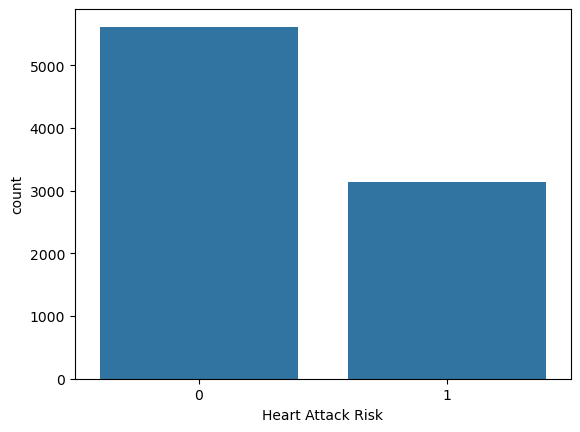

In [92]:
sns.countplot(x='Heart Attack Risk', data=heart_attack_df)

C:\Users\Techno Shield\AppData\Local\Temp\ipykernel_14412\1202661602.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




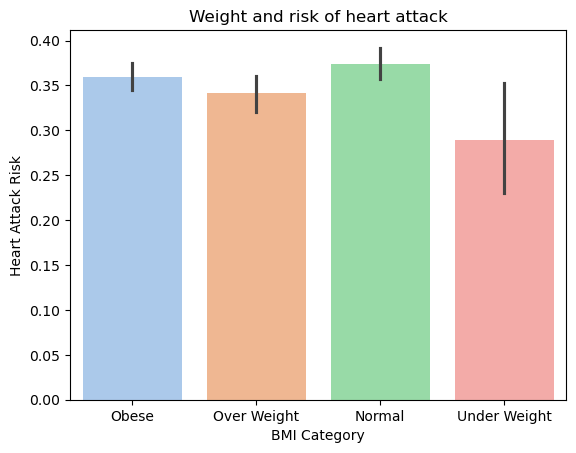

In [102]:
sns.barplot(heart_attack_df, x= 'BMI Category', y= 'Heart Attack Risk', palette= 'pastel')
plt.title("Weight and risk of heart attack")
plt.show()

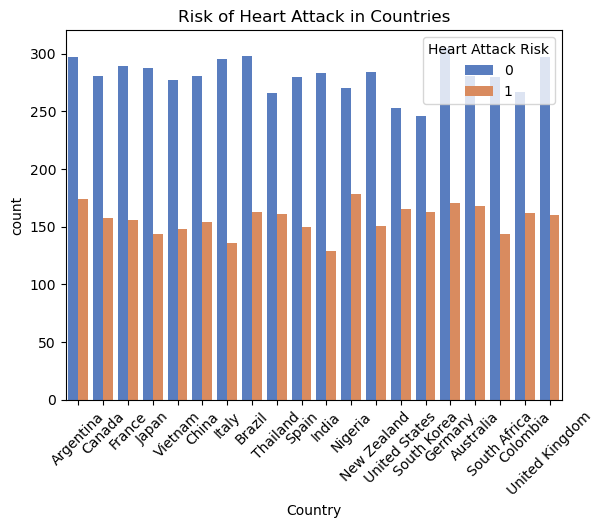

In [134]:
sns.countplot(data=heart_attack_df, x='Country', hue='Heart Attack Risk', palette='muted')
plt.title("Risk of Heart Attack in Countries")
plt.xticks(rotation=45)
plt.show()

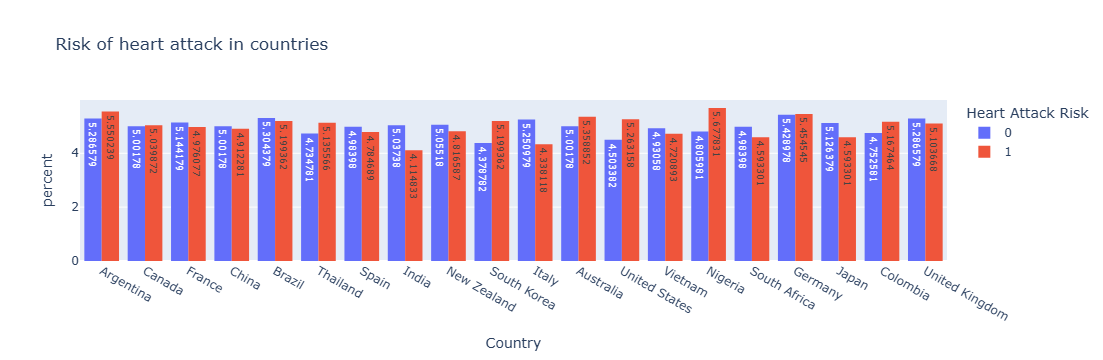

In [137]:
fig = px.histogram(heart_attack_df, x='Country', color='Heart Attack Risk', barmode='group',histnorm='percent',text_auto=True, title='Risk of heart attack in countries')
fig.show()

In [138]:
train_size = int(len(heart_attack_df) * 0.75)
train_df, val_df = heart_attack_df[:train_size], heart_attack_df[train_size:]

In [139]:
train_df.shape

(6564, 26)

In [140]:
val_df.shape 

(2189, 26)

In [141]:
target_col = ['Heart Attack Risk']
train_df[target_col]

,Heart Attack Risk
0,0
1,0
2,0
6,1
7,1
...,...
6569,0
6570,1
6571,0
6572,0


In [143]:
input_cols = heart_attack_df.columns[1:25]
input_cols

Index(['Age', 'Sex', 'Cholesterol', 'Systolic', 'Diastolic', 'Heart Rate',
       'Diabetes', 'Family History', 'Smoking', 'Alcohol Consumption',
       'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems',
       'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income',
       'Triglycerides', 'BMI Category', 'Physical Activity Days Per Week',
       'Sleep Hours Per Day', 'Country', 'Continent', 'Hemisphere'],
      dtype='object')

In [144]:
train_df[input_cols].nunique()

Age                                  73
Sex                                   2
Cholesterol                         281
Systolic                             91
Diastolic                            51
Heart Rate                           71
Diabetes                              2
Family History                        2
Smoking                               2
Alcohol Consumption                   2
Exercise Hours Per Week            6564
Diet                                  3
Previous Heart Problems               2
Medication Use                        2
Stress Level                         10
Sedentary Hours Per Day            6564
Income                             6483
Triglycerides                       771
BMI Category                          4
Physical Activity Days Per Week       8
Sleep Hours Per Day                   7
Country                              20
Continent                             6
Hemisphere                            2
dtype: int64

In [150]:
numeric_cols = heart_attack_df.select_dtypes(include= 'number').columns.drop('Heart Attack Risk')
numeric_cols

Index(['Age', 'Cholesterol', 'Systolic', 'Diastolic', 'Heart Rate', 'Diabetes',
       'Family History', 'Smoking', 'Alcohol Consumption',
       'Exercise Hours Per Week', 'Previous Heart Problems', 'Medication Use',
       'Stress Level', 'Sedentary Hours Per Day', 'Income', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day'],
      dtype='object')

In [154]:
categorical_cols = heart_attack_df.select_dtypes(include='object').columns.drop('Patient ID')
categorical_cols

Index(['Sex', 'Diet', 'BMI Category', 'Country', 'Continent', 'Hemisphere'], dtype='object')

In [156]:
train_inputs = train_df[input_cols].copy()
train_target = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_target = val_df[target_col].copy()

In [157]:
from sklearn.preprocessing import StandardScaler

In [158]:
scaler = StandardScaler()

In [159]:
scaler = scaler.fit(train_df[numeric_cols])

In [160]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])

In [161]:
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

In [163]:
train_inputs.head(5)

,Age,Sex,Cholesterol,Systolic,Diastolic,Heart Rate,Diabetes,Family History,Smoking,Alcohol Consumption,...,Stress Level,Sedentary Hours Per Day,Income,Triglycerides,BMI Category,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere
0,0.623861,Male,-0.640763,0.857825,0.190181,-0.144421,-1.370747,-0.983680,0.344674,-1.214542,...,1.245691,0.182015,1.273544,-0.600155,Obese,-1.537279,-0.512939,Argentina,South America,Southern Hemisphere
1,-1.532105,Male,1.603492,1.122886,0.529776,1.125481,0.729529,1.016591,0.344674,0.823355,...,-1.554554,-0.294650,1.575409,-0.828111,Over Weight,-1.097654,-0.009134,Canada,North America,Northern Hemisphere
2,-1.532105,Female,0.797544,1.463679,0.937289,-0.144421,0.729529,-0.983680,-2.901293,-1.214542,...,1.245691,1.004122,0.949896,0.745236,Over Weight,0.221219,-1.520550,France,Europe,Northern Hemisphere
6,1.701843,Male,1.219117,-1.262662,-0.828602,0.441687,-1.370747,-0.983680,0.344674,0.823355,...,0.545630,-1.546128,0.394436,-0.609094,Over Weight,0.221219,1.502283,Canada,North America,Northern Hemisphere
7,1.420631,Male,-0.491973,-0.164553,-1.168197,1.565063,-1.370747,-0.983680,0.344674,0.823355,...,-0.504462,1.315932,-0.452496,-0.224697,Normal,1.100467,-0.009134,Japan,Asia,Northern Hemisphere


In [166]:
train_inputs[numeric_cols].corrwith(heart_attack_df['Heart Attack Risk']).sort_values(ascending=False)

Diabetes                           0.024666
Cholesterol                        0.019409
Systolic                           0.014617
Exercise Hours Per Week            0.009095
Medication Use                     0.008811
Physical Activity Days Per Week    0.007476
Heart Rate                         0.007269
Income                             0.006787
Triglycerides                      0.006580
Age                                0.004243
Sedentary Hours Per Day            0.003248
Stress Level                      -0.002857
Previous Heart Problems           -0.003659
Family History                    -0.005498
Smoking                           -0.008511
Alcohol Consumption               -0.014076
Sleep Hours Per Day               -0.016269
Diastolic                         -0.023178
dtype: float64

In [175]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder = encoder.fit(train_inputs[categorical_cols])

In [176]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

In [177]:
encoded_cols

['Sex_Female',
 'Sex_Male',
 'Diet_Average',
 'Diet_Healthy',
 'Diet_Unhealthy',
 'BMI Category_Normal',
 'BMI Category_Obese',
 'BMI Category_Over Weight',
 'BMI Category_Under Weight',
 'Country_Argentina',
 'Country_Australia',
 'Country_Brazil',
 'Country_Canada',
 'Country_China',
 'Country_Colombia',
 'Country_France',
 'Country_Germany',
 'Country_India',
 'Country_Italy',
 'Country_Japan',
 'Country_New Zealand',
 'Country_Nigeria',
 'Country_South Africa',
 'Country_South Korea',
 'Country_Spain',
 'Country_Thailand',
 'Country_United Kingdom',
 'Country_United States',
 'Country_Vietnam',
 'Continent_Africa',
 'Continent_Asia',
 'Continent_Australia',
 'Continent_Europe',
 'Continent_North America',
 'Continent_South America',
 'Hemisphere_Northern Hemisphere',
 'Hemisphere_Southern Hemisphere']

In [178]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

In [179]:
train_inputs[encoded_cols]

,Sex_Female,Sex_Male,Diet_Average,Diet_Healthy,Diet_Unhealthy,BMI Category_Normal,BMI Category_Obese,BMI Category_Over Weight,BMI Category_Under Weight,Country_Argentina,...,Country_United States,Country_Vietnam,Continent_Africa,Continent_Asia,Continent_Australia,Continent_Europe,Continent_North America,Continent_South America,Hemisphere_Northern Hemisphere,Hemisphere_Southern Hemisphere
0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
7,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6569,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6570,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6571,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6572,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [186]:
train_inputs[numeric_cols]

,Age,Cholesterol,Systolic,Diastolic,Heart Rate,Diabetes,Family History,Smoking,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day
0,0.623861,-0.640763,0.857825,0.190181,-0.144421,-1.370747,-0.983680,0.344674,-1.214542,-1.020598,-0.993016,-0.997565,1.245691,0.182015,1.273544,-0.600155,-1.537279,-0.512939
1,-1.532105,1.603492,1.122886,0.529776,1.125481,0.729529,1.016591,0.344674,0.823355,-1.426881,1.007033,-0.997565,-1.554554,-0.294650,1.575409,-0.828111,-1.097654,-0.009134
2,-1.532105,0.797544,1.463679,0.937289,-0.144421,0.729529,-0.983680,-2.901293,-1.214542,-1.381143,1.007033,1.002441,1.245691,1.004122,0.949896,0.745236,0.221219,-1.520550
6,1.701843,1.219117,-1.262662,-0.828602,0.441687,-1.370747,-0.983680,0.344674,0.823355,-1.032677,-0.993016,-0.997565,0.545630,-1.546128,0.394436,-0.609094,0.221219,1.502283
7,1.420631,-0.491973,-0.164553,-1.168197,1.565063,-1.370747,-0.983680,0.344674,0.823355,-1.148310,-0.993016,1.002441,-0.504462,1.315932,-0.452496,-0.224697,1.100467,-0.009134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6569,-0.266647,1.541496,0.554899,-1.236116,-0.730530,-1.370747,-0.983680,0.344674,-1.214542,-0.692115,-0.993016,-0.997565,0.545630,-0.098994,-0.866329,1.634714,0.221219,0.494672
6570,-1.625842,1.219117,-1.224796,-1.032359,1.516221,0.729529,-0.983680,0.344674,-1.214542,-0.008430,-0.993016,1.002441,-0.504462,-1.457369,0.091182,-1.319782,0.221219,-0.512939
6571,0.202041,1.219117,0.630630,-0.013576,-1.170112,0.729529,-0.983680,0.344674,-1.214542,1.701877,-0.993016,1.002441,-0.504462,1.624167,0.286991,-1.686301,-0.658030,0.494672
6572,-0.829072,1.417504,-0.278150,1.412722,1.467378,0.729529,1.016591,-2.901293,-1.214542,1.060928,-0.993016,1.002441,-1.554554,-0.010649,0.615359,-1.610315,-0.658030,-0.512939


In [180]:
selected_cols = encoded_cols + list(numeric_cols)
x_train = train_inputs[selected_cols]
x_train.sample(5)

,Sex_Female,Sex_Male,Diet_Average,Diet_Healthy,Diet_Unhealthy,BMI Category_Normal,BMI Category_Obese,BMI Category_Over Weight,BMI Category_Under Weight,Country_Argentina,...,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day
1540,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.823355,-0.284696,-0.993016,1.002441,-1.554554,0.911818,0.056664,-1.583497,-0.218406,-0.009134
6457,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-1.214542,-1.349210,-0.993016,1.002441,1.245691,0.302349,0.513118,0.427885,1.100467,-1.520550
3367,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-1.214542,-1.246351,-0.993016,-0.997565,-1.554554,-0.187650,0.023323,0.164170,1.540092,-0.512939
1787,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.823355,-0.880548,-0.993016,1.002441,-1.554554,-1.025182,-1.331158,-1.355540,-0.218406,-0.009134
844,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.823355,-1.612537,-0.993016,-0.997565,1.595722,1.734013,-0.229206,-0.948794,-0.658030,0.998478


In [188]:
x_val = val_inputs[selected_cols]
x_val.shape

(2189, 55)

In [199]:
train_target = train_target.values.ravel()
val_target = val_target.values.ravel()

In [190]:
def return_mean(inputs):
    return np.full(len(inputs), heart_attack_df['Heart Attack Risk'].mean())
return_mean(x_train)

array([0.35816292, 0.35816292, 0.35816292, ..., 0.35816292, 0.35816292,
       0.35816292])

In [191]:
return_mean(x_val)

array([0.35816292, 0.35816292, 0.35816292, ..., 0.35816292, 0.35816292,
       0.35816292])

In [192]:
from sklearn.metrics import accuracy_score 

In [193]:
def try_model_train (model): 
    model.fit(x_train, train_target)
    train_preds = model.predict(x_train)
    train_accuracy = accuracy_score(train_target, train_preds)
    return train_accuracy

In [194]:
def try_model_val (model):
    val_preds = model.predict(x_val)
    val_accuracy = accuracy_score(val_target, val_preds)
    return val_accuracy 

In [216]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier( random_state = 41, n_jobs=-1, n_estimators=120, max_depth=9)
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state = 41, max_depth=5,min_samples_leaf= 5, min_samples_split=8)

In [200]:
try_model_train(lr)

0.6418342474101157

In [201]:
try_model_val(lr)

0.6423024211968935

In [206]:
try_model_train(rf)

0.6550883607556368

In [207]:
try_model_val(rf)

0.6423024211968935

In [217]:
try_model_train(dt)

0.6450335161486899

In [218]:
try_model_val(dt)

0.6372772955687529

In [237]:
models =['Baseline', 'Logistic Regression', 'Random Forest', 'Decision Tree']
accuracy = [0.358,0.642,0.642,0.637]

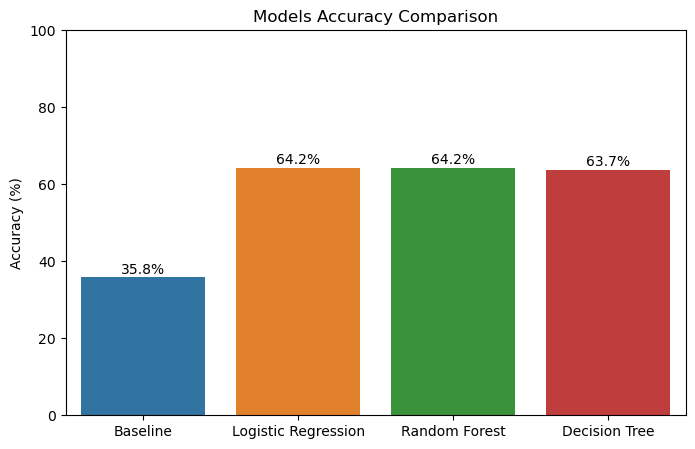

In [245]:
accuracy_percent = [a * 100 for a in accuracy]
plt.figure(figsize=(8,5))
ax = sns.barplot(x=models, y=accuracy_percent, hue=models)

plt.ylim(0, 100)
plt.title('Models Accuracy Comparison')
plt.ylabel('Accuracy (%)')
for i,v in enumerate(accuracy_percent):
    ax.text(i,v + 1, f"{v:.1f}%", ha='center')

plt.show()